# Boston Housing Price Predictor
### Predicting median home value (MEDV) from neighborhood + property features

## Data Cleaning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("boston.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [2]:
df.shape

(506, 14)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [4]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## EDA
quick look before touching anything, want to see what I'm working with

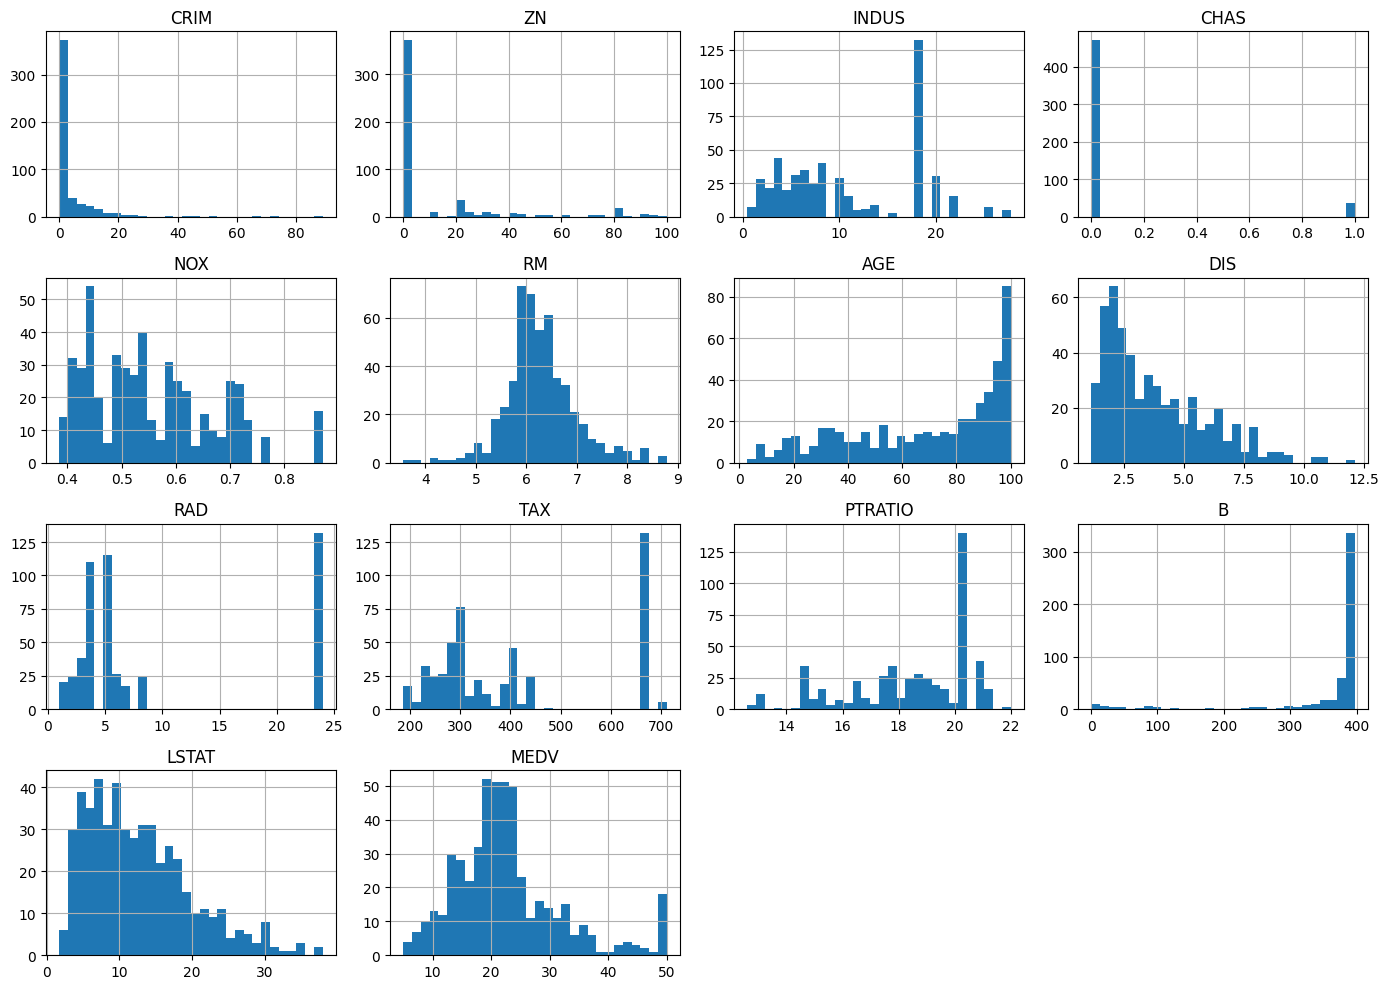

In [5]:
df.hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

CRIM, DIS and LSTAT are all skewed hard to one side, gonna need to log those later. Also check MEDV itself:

In [6]:
df["MEDV"].value_counts().sort_index(ascending=False).head(10)

MEDV
50.0    16
48.8     1
48.5     1
48.3     1
46.7     1
46.0     1
45.4     1
44.8     1
44.0     1
43.8     1
Name: count, dtype: int64

16 houses sitting at exactly 50.0 - that's not a real price, it's how the dataset caps anything above 50k. dropping those later so the model isn't trained on fake numbers.

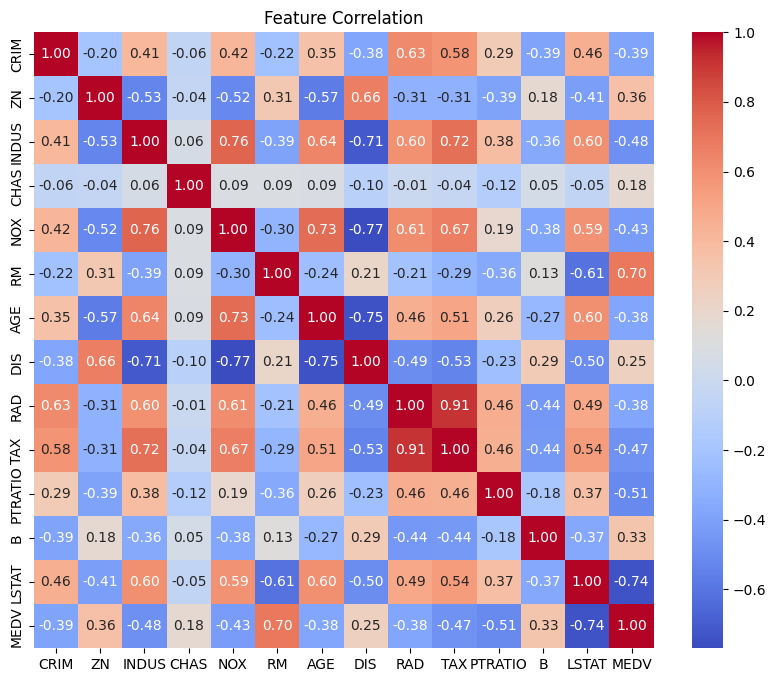

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

RM and LSTAT are clearly the two biggest drivers of price (positive and negative). worth combining them later.

## Feature Engineering

In [8]:
# skewed columns, log them so the relationship with price is more linear
df["CRIM"] = np.log1p(df["CRIM"])
df["DIS"] = np.log1p(df["DIS"])
df["LSTAT"] = np.log1p(df["LSTAT"])

# rooms and lower-status % interact a lot, worth its own column
df["RM_LSTAT"] = df["RM"] * df["LSTAT"]
df["TAX_per_room"] = df["TAX"] / df["RM"]
df["DIS_RAD"] = df["DIS"] / df["RAD"]

# drop the fake capped prices
print("rows at the 50k cap:", (df["MEDV"] == 50).sum())
df = df[df["MEDV"] < 50]
df.shape

rows at the 50k cap: 16


(490, 17)

In [9]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,RM_LSTAT,TAX_per_room,DIS_RAD
0,0.006300,18.0,2.31,0,0.538,6.575,65.2,1.627278,1,296,15.3,396.90,1.788421,24.0,11.758865,45.019011,1.627278
1,0.026944,0.0,7.07,0,0.469,6.421,78.9,1.786261,2,242,17.8,396.90,2.316488,21.6,14.874169,37.688834,0.893131
2,0.026924,0.0,7.07,0,0.469,7.185,61.1,1.786261,2,242,17.8,392.83,1.615420,34.7,11.606793,33.681280,0.893131
3,0.031857,0.0,2.18,0,0.458,6.998,45.8,1.954757,3,222,18.7,394.63,1.371181,33.4,9.595523,31.723350,0.651586
4,0.066770,0.0,2.18,0,0.458,7.147,54.2,1.954757,3,222,18.7,396.90,1.845300,36.2,13.188361,31.061984,0.651586


## Modeling

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

x = df.drop("MEDV", axis=1)
y = df["MEDV"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

baseline first - just guessing the average price every time. anything real needs to beat this by a mile or it's not actually learning anything

In [11]:
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
print("baseline R2:", r2_score(y_test, baseline_pred))
print("baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))

baseline R2: -0.07554847092916006
baseline RMSE: 7.41247446955941


In [12]:
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

lr = LinearRegression()
lr.fit(x_train_s, y_train)

y_pred = lr.predict(x_test_s)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 9.107567929741627
RMSE: 3.0178747372516352
R2: 0.8217186207728203


## Is It Actually Good?

In [13]:
error_pct = rmse / y_test.mean() * 100
print(f"off by ${rmse*1000:,.0f} on average, about {error_pct:.1f}% of the average home price")

off by $3,018 on average, about 15.0% of the average home price


predicted vs actual - the closer the dots hug the red line, the better

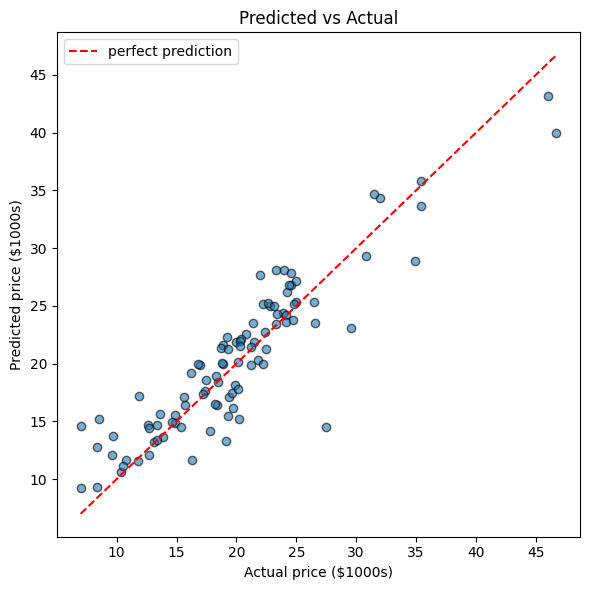

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("Actual price ($1000s)")
plt.ylabel("Predicted price ($1000s)")
plt.title("Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

residuals - want these scattered randomly around 0, not shaped like a funnel or a curve

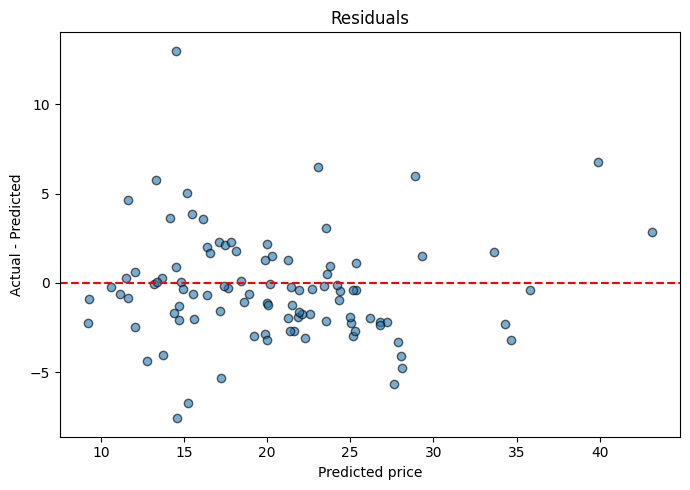

In [15]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor="k")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted price")
plt.ylabel("Actual - Predicted")
plt.title("Residuals")
plt.tight_layout()
plt.show()

## Model Comparison
curious how much a non-linear model would pick up on the same data

In [16]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(x_train, y_train)
y_pred_gb = gb.predict(x_test)

results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Gradient Boosting"],
    "R2": [
        r2_score(y_test, baseline_pred),
        r2,
        r2_score(y_test, y_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, baseline_pred)),
        rmse,
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ]
})
results

,Model,R2,RMSE
0,Baseline,-0.075548,7.412474
1,Linear Regression,0.821719,3.017875
2,Gradient Boosting,0.886337,2.409674


/tmp/ipykernel_482/1405373984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="R2", palette="viridis")


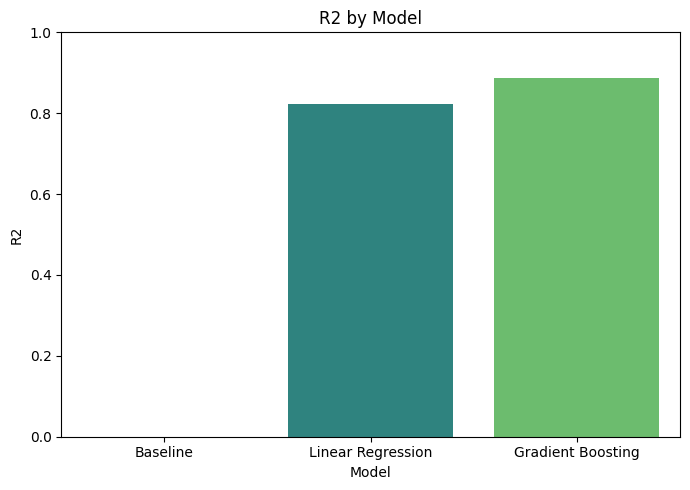

In [17]:
plt.figure(figsize=(7,5))
sns.barplot(data=results, x="Model", y="R2", palette="viridis")
plt.ylim(0,1)
plt.title("R2 by Model")
plt.tight_layout()
plt.show()